In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
data = pd.read_csv("data/parsed_save2.csv")

In [26]:
data.head()

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.5,1,0,0,0,0.0,0.000,0.000,0.000,0.000,0.2,0.2,0,0.167,0.667,0,1.333,0.175
1,1,0.357,0.5,0,1,0,0,0.5,0.286,0.429,0.000,0.000,0.4,0.8,0,0.167,0.000,0,0.571,0.175
2,2,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.000,0,0.000,0.175
3,3,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.400,0,0.400,0.175
4,4,0.357,0.5,0,0,0,1,0.5,0.286,0.429,0.929,0.786,0.4,0.8,0,0.167,0.000,0,0.514,0.175


In [27]:
data.columns

Index(['Unnamed: 0', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop',
       'stage_turn', 'stage_river', 'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'if_fold', 'hero_bet_ratio', 'result'],
      dtype='str')

In [28]:
temp = data[data["stage_pre"] == 1]
temp.loc[temp["facing_ratio"] <= temp["hero_bet_ratio"]]

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.167,0.667,0,1.333,0.175
9,9,0.429,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.500,0.667,0,0.667,-0.020
12,12,0.571,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.833,0.833,0,0.833,0.085
14,14,0.357,0.571,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.000,0.667,0,1.333,-0.020
18,18,0.714,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.500,0.667,0,1.333,0.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,1252,0.786,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.000,0.667,0,1.333,0.275
1262,1262,1.000,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.667,0.667,0,0.667,-0.020
1264,1264,1.000,0.786,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.833,0.667,0,1.333,0.045
1275,1275,0.857,0.714,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.833,0.667,0,1.333,-0.190


In [29]:
temp.loc[temp["if_fold"] == 1, "action"] = "fold"
#temp.loc[(temp["if_fold"] == 0) & (temp["hero_bet_ratio"] == 0), "action"] = "check"
#try with check
temp.loc[(temp["facing_ratio"] < temp["hero_bet_ratio"]) & (temp["action"] != 0) & (temp["action"] != 1), "action"] = "raise"
temp.fillna({"action": "call"}, inplace=True)
temp["action"].value_counts()

action
fold     355
raise    176
call     176
Name: count, dtype: int64

In [30]:
temp.drop(columns=["Unnamed: 0","if_fold", "result"], inplace=True)


In [31]:
temp.columns

Index(['hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio', 'action'],
      dtype='str')

In [32]:
from zlib import crc32
import numpy as np

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id: is_id_in_test_set(id, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [33]:
temp_with_id = temp.reset_index()
temp_with_id.columns
train_set, test_set = split_data_with_id_hash(temp_with_id, test_ratio=0.2, id_column="index")

In [34]:
train_set.columns

Index(['index', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio', 'action'],
      dtype='str')

In [35]:
def x_y_separator(df, y = "action"):
    label = df[y]
    df.drop(columns=[y], inplace=True)
    return df, label

train_set, label = x_y_separator(train_set, "action")

In [36]:
def position_mapping(df, y = "position_norm"):
    POSITION_MAP = {
        0.000: "BTN",
        0.167: "SB",
        0.333: "BB",
        0.500: "UTG",
        0.667: "HJ",
        0.833: "CO",
    }

    temp = df[y].round(3).map(POSITION_MAP)
    df[y] = temp
    return df

train_set = position_mapping(train_set)


In [37]:
def hand_label(df):
    # Sorts each row descending and re-assigns the columns
    df[['hero_r1', 'hero_r2']] = np.sort(df[['hero_r1', 'hero_r2']].values, axis=1)[:, ::-1]
    return df

train_set = hand_label(train_set)

In [38]:
train_set.columns

Index(['index', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio'],
      dtype='str')

In [39]:
train_set.drop(columns=['index', 'stage_pre', 'stage_flop',
       'stage_turn', 'stage_river',
       'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'gut_po', 'hero_bet_ratio'], inplace=True)

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

x_train = train_set
y_train = label

categorical_cols = ["position_norm"]
numeric_cols = [
    "hero_r1",
    "hero_r2",
    "suit_po",
    "stra_po",
    "facing_ratio"
]
interact_cols = ["position_norm", "facing_ratio"]
preprocessor = ColumnTransformer(
    transformers=[
        ("position", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("numerical", StandardScaler(), numeric_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False

).set_output(transform="pandas")

x_train_prepared = preprocessor.fit_transform(x_train)
print(x_train_prepared.columns)

Index(['position_norm_BB', 'position_norm_BTN', 'position_norm_CO',
       'position_norm_HJ', 'position_norm_SB', 'position_norm_UTG', 'hero_r1',
       'hero_r2', 'suit_po', 'stra_po', 'facing_ratio'],
      dtype='str')


In [41]:
def create_single_interaction(df):

    for col_name in df:
        if 'position' in col_name:
            df[col_name] = df[col_name] * df['facing_ratio']

    return df

from sklearn.dummy import DummyClassifier

DummyClassifier(strategy="most_frequent")

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ('model', LogisticRegression(l1_ratio=0)),
    ])

param_grid = { "model__C": [0.01, 0.1, 1, 10, 100, 1000, 10000],
               "model__class_weight": [None, "balanced"]}

ss = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=5,random_state=42,)
search = GridSearchCV(pipeline, param_grid=param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True)

model = search.fit(x_train, y_train)

print(search.best_params_)
print(search.best_score_)
#0.519 if added position * facing_ratio

{'model__C': 100, 'model__class_weight': None}
0.6053184367515894


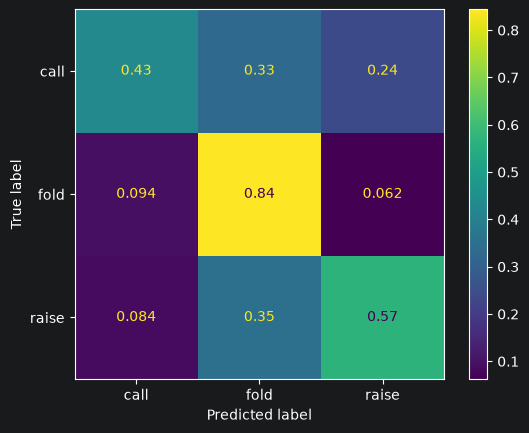

In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

prediction = model.predict(x_train)


ConfusionMatrixDisplay.from_predictions(
    y_train,
    prediction,
    labels=model.classes_,
    normalize='true',
)

plt.show()


In [44]:
test_x, test_label = x_y_separator(test_set, "action")
test_x = position_mapping(test_set)
test_x.drop(columns=['index', 'stage_flop',
       'stage_turn', 'stage_river',
       'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'hero_bet_ratio'], inplace=True)
predicted_y = model.predict(test_x)
confusion_matrix(test_label, predicted_y)

array([[14, 12, 11],
       [ 5, 38, 24],
       [ 2, 10, 21]])

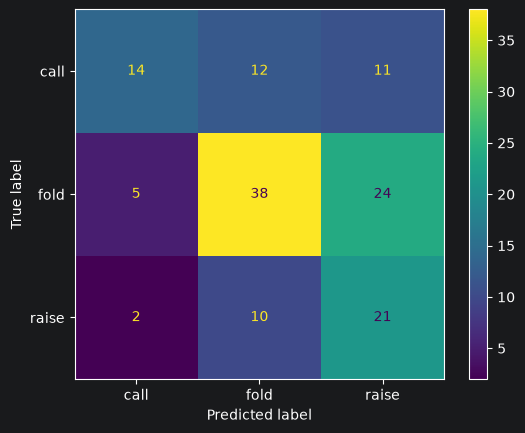

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    test_label,
    predicted_y,
    labels=model.classes_,
    normalize=None,
)

plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    test_label,
    predicted_y,
)
)

              precision    recall  f1-score   support

        call       0.67      0.38      0.48        37
        fold       0.63      0.57      0.60        67
       raise       0.38      0.64      0.47        33

    accuracy                           0.53       137
   macro avg       0.56      0.53      0.52       137
weighted avg       0.58      0.53      0.54       137

